# Interpreting Structural Patterns in Old Babylonian Economic Tablets
### An Interpretable Machine Learning Approach to Archaeological Geometry

---

## **Introduction**
### *Recapitulation of previous notebook*


The previous notebook established that the physical dimensions of Old Babylonian economic tablets contain detectable structural variation. Using clustering methods, anomaly detection, and classification models, the analysis demonstrated that certain tablets occupy unusual geometric positions within the broader archaeological dataset.

However, identifying anomalous tablets is only the first step in computational interpretation.
The more important archaeological question is understanding

*What kind of dimensional relationships produce these anomalies?*

This notebook therefore moves beyond detection toward structural interpretation. Rather than treating anomalous tablets as isolated outliers, the analysis investigates whether recurring geometric patterns exist within the physical organization of the tablets themselves.
The study focuses on three core measurements:

- height
- width
- thickness

Although simple individually, these dimensions may interact in nonlinear ways that reflect deeper archaeological processes such as:


- scribal conventions
- administrative standardization
- production variability
- storage requirements
- specialized economic functions.

Unlike purely linear models, these approaches can identify conditional geometric relationships inside the archaeological measurements. A tablet may appear structurally unusual not because of a single large measurement, but because of a specific combination of dimensions occurring together.

---
### *Dataset Continuity*
The dataset used in this notebook originates from the public archival repositories of the "Cuneiform Digital Library Initiative" and was previously cleaned, standardized, and processed during Notebook 1 using PySpark workflows. The current notebook continues from that stage using pandas-based interpretable machine learning methods focused on archaeological explanation rather than large-scale preprocessing.

The broader objective of this analysis is not only predictive classification, but interpretability.
By examining how machine learning models partition dimensional space, the notebook attempts to investigate whether ancient economic tablets preserve underlying structural conventions that remain computationally detectable thousands of years later.

---

## Loading the Prepared Archaeological Dataset

Since the archaeological measurements were already cleaned and standardized in Notebook 1, this notebook begins by loading the processed dataset directly from Google Drive.

The dataset primarily contains:
- tablet height
- tablet width
- tablet thickness
- anomaly generated during earlier analysis.

These anomaly labels now serve as the target variable for interpretable nonlinear classification models.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
df=pd.read_csv("/content/drive/MyDrive/Ancient_Data /babylon_anomalies.csv")
model_df = df[["id_text",
        "provenience",
        "height",
        "width",
        "thickness",
        "distance",
        "anomaly"]].copy()
model_df.rename(columns={"anomaly": "anomaly_label"},inplace=True)
print("Dataset Shape:")
print(model_df.shape)
print("Column Names:")
print(model_df.columns)
print("First Five Rows:")
display(model_df.head())
print("\nMissing Values:")
print(model_df.isnull().sum())
print("\nAnomaly Label Distribution:")
print(model_df["anomaly_label"].value_counts())


Dataset Shape:
(4776, 7)
Column Names:
Index(['id_text', 'provenience', 'height', 'width', 'thickness', 'distance',
       'anomaly_label'],
      dtype='object')
First Five Rows:


,id_text,provenience,height,width,thickness,distance,anomaly_label
0,135973,Nippur (mod. Nuffar),30.0,30.0,13.0,0.987963,0
1,223277,Nippur (mod. Nuffar),90.0,48.0,28.0,1.221925,0
2,225791,uncertain (mod. uncertain),35.0,42.0,16.0,0.733858,0
3,225792,uncertain (mod. uncertain),23.0,22.0,10.0,1.843364,1
4,235703,Larsa (mod. Tell as-Senkereh),62.0,45.0,17.0,1.172083,0



Missing Values:
id_text          0
provenience      0
height           0
width            0
thickness        0
distance         0
anomaly_label    0
dtype: int64

Anomaly Label Distribution:
anomaly_label
0    4490
1     286
Name: count, dtype: int64


## Initial Observations from the Dataset

The prepared dataset contains 4,776 Old Babylonian economic tablets with complete dimensional information and anomaly classifications inherited from the previous notebook.

The anomaly distribution reveals a strong class imbalance within the dataset. Out of 4,776 tablets, only 286 tablets were classified as anomalous, while 4,490 belong to the non-anomalous category.

Most economic tablets in large administrative archives were likely produced according to relatively stable scribal and organizational conventions. This imbalance is itself historically meaningful because it suggests that anomalous dimensional configurations were not dominant production forms within the Old Babylonian administrative system.

---

## Problem Statement

While Notebook 1 successfully identified anomalous Old Babylonian economic tablets through clustering and distance-based classification methods, the structural causes underlying those anomalies remain unclear.

This analysis investigates whether combinations of:

- height
- width
- thickness

produce recurring nonlinear structural patterns within the dataset.

Understanding these relationships is important because dimensional variation may reflect deeper historical processes such as:

- scribal standardization
- administrative specialization
- production constraints
- regional variation
- differences in economic recording practices.


This study therefore attempts to answer the following broader question:

***Can interpretable machine learning models reveal hidden structural organization within the geometry of Old Babylonian economic tablets?***

---

## Exploratory Data Analysis

Before constructing nonlinear classification models, it is important to examine the overall distribution of tablet measurements within the archaeological dataset.

Exploratory analysis helps identify:
- dominant dimensional ranges
- variability in tablet geometry
- potential asymmetry in measurements
- visible structural differences between anomalous and normal tablets

This stage is particularly important in archaeological machine learning because numerical variation often reflects underlying material and administrative practices rather than purely statistical behavior.


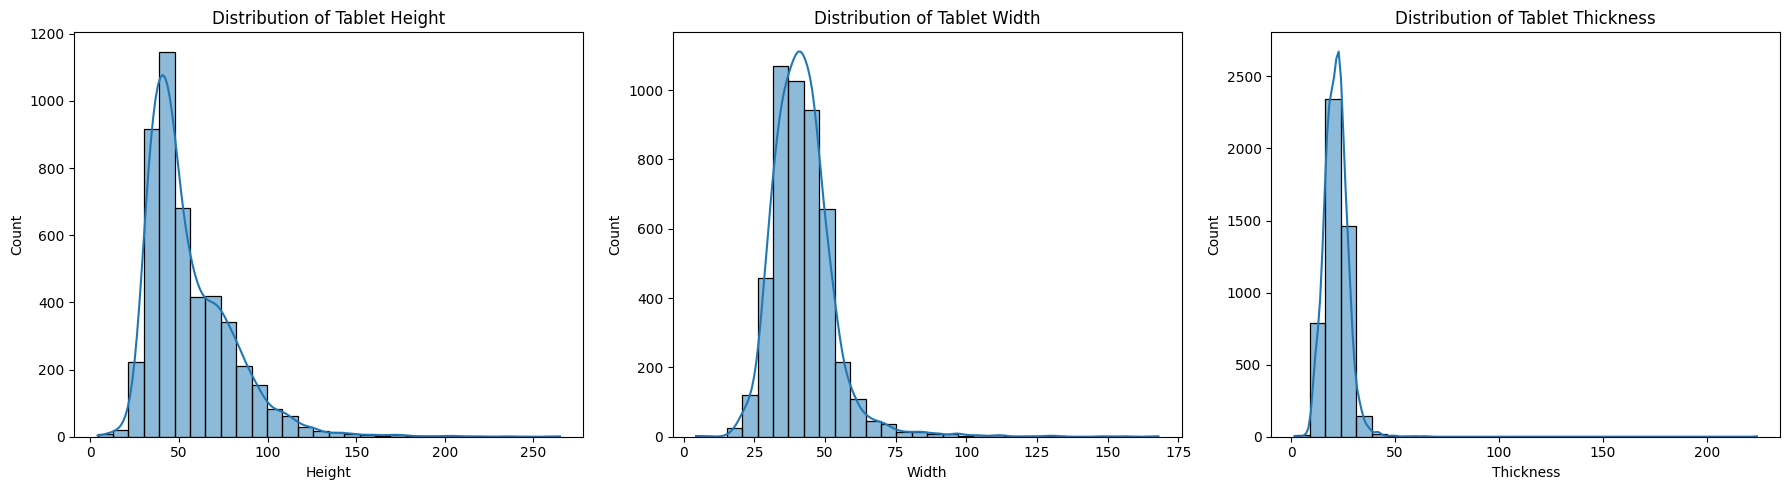

Summary Statistics for Tablet Measurements:



,height,width,thickness
count,4776.000000,4776.000000,4776.000000
mean,55.516436,42.082056,21.589803
std,23.887684,11.323597,6.229836
min,4.000000,4.300000,1.600000
25%,39.000000,35.000000,18.000000
50%,48.000000,41.000000,22.000000
75%,68.000000,47.000000,25.000000
max,265.000000,168.000000,224.000000


In [9]:
fig, axes=plt.subplots(1, 3, figsize=(18, 5))
# Height Distribution
sns.histplot(
    data=model_df,
    x="height",
    kde=True,
    bins=30,
    ax=axes[0]
)

axes[0].set_title("Distribution of Tablet Height")
axes[0].set_xlabel("Height")

# Width Distribution
sns.histplot(
    data=model_df,
    x="width",
    kde=True,
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Distribution of Tablet Width")
axes[1].set_xlabel("Width")

# Thickness Distribution
sns.histplot(
    data=model_df,
    x="thickness",
    kde=True,
    bins=30,
    ax=axes[2]
)
axes[2].set_title("Distribution of Tablet Thickness")
axes[2].set_xlabel("Thickness")
plt.tight_layout()
plt.show()
print("Summary Statistics for Tablet Measurements:\n")
display(model_df[["height", "width", "thickness"]].describe())

## Interpretation of Histograms

The distributions already suggest that Old Babylonian economic tablets were not produced as completely uniform administrative objects. Although most tablets fall within a fairly consistent dimensional range, the dataset also contains a smaller group of unusually large or structurally distinct tablets.

1. The height distribution is strongly right-skewed, with most tablets concentrated around moderate values and a smaller number extending into much larger sizes. This pattern implies that while a dominant production norm existed, certain tablets were intentionally created in larger formats. These larger tablets may have served specialized administrative purposes or contained longer and more detailed economic records.

2. The width distribution appears comparatively more stable and centralized. Unlike height, width shows less variation and resembles a more balanced distribution overall. This may indicate that widths were maintained with greater consistency during tablet preparation, possibly because width influenced writing layout and the practical organization of cuneiform text.

3. Thickness presents the most striking structural pattern in the dataset. Most tablets cluster within a very narrow range, creating a sharp central peak that suggests strong consistency in tablet depth across ordinary records. At the same time, a small number of tablets extend far beyond the range, producing an unusually long tail of extreme values.

Archaeologically, this combination is important. It suggests that the majority of tablets followed relatively standardized production practices, while a smaller subset deviated significantly from those conventions. These extreme cases may reflect differences in administrative function, storage requirements, scribal traditions, or even distinct production environments.

Taken together, the distributions indicate that the anomalies identified in Notebook 1 are unlikely to represent random statistical noise alone. Instead, the dataset appears to contain recurring geometric irregularities hidden within the physical structure of the tablets themselves.

This makes the archaeological dataset particularly suitable for interpretable nonlinear machine learning models, since such methods are designed to identify conditional dimensional relationships that may not be visible through simple linear analysis.

---

## Preparing Data for Nonlinear Classification

The exploratory analysis suggests that the structure of the tablets contains both strong regularity and a smaller number of extreme geometric forms. These asymmetrical patterns indicate that simple linear separation may not fully capture the internal organization of the archaeological dataset.

The next stage of the analysis therefore prepares the data for interpretable nonlinear classification models.

The study focuses on three primary measurements:

- height
- width
- thickness

These dimensions are used as predictive variables, while the anomaly labels generated in Notebook 1 serve as the target classification categories.

The dataset is then divided into training and testing subsets in order to evaluate how effectively different machine learning models can distinguish structurally anomalous tablets from more typical economic records.

Because anomalous tablets form a relatively small proportion of the dataset, stratified sampling is used during the split to preserve the original class distribution across both subsets.

In [10]:
from sklearn.model_selection import train_test_split
X=model_df[
    [
        "height",
        "width",
        "thickness"
    ]
]
y=model_df["anomaly_label"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=726,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)
print("\nTraining Label Distribution:")
print(y_train.value_counts())
print("\nTesting Label Distribution:")
print(y_test.value_counts())

Training Set Shape: (3820, 3)
Testing Set Shape: (956, 3)

Training Label Distribution:
anomaly_label
0    3591
1     229
Name: count, dtype: int64

Testing Label Distribution:
anomaly_label
0    899
1     57
Name: count, dtype: int64


---
## Decision Tree Classification

Decision Trees are among the most interpretable machine learning methods for studying structured archaeological data. Unlike linear models that attempt to separate observations using a single continuous boundary, Decision Trees classify observations through a sequence of measurement-based rules.

At each stage, the algorithm searches for dimensional thresholds that best divide the tablets into increasingly distinct structural groups.

Here the model may learn rules such as:

- tablets thicker than a certain value
- tablets with unusually narrow widths
- combinations of height and thickness occurring together

This makes Decision Trees especially valuable for archaeological interpretation because the resulting classification process can be visualized directly.

The model produces a hierarchy of dimensional decisions that can be examined in relation to possible production practices, administrative organization, or scribal conventions.

Classification Report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       899
           1       0.92      0.39      0.54        57

    accuracy                           0.96       956
   macro avg       0.94      0.69      0.76       956
weighted avg       0.96      0.96      0.95       956


Decision Tree Accuracy:
0.9613


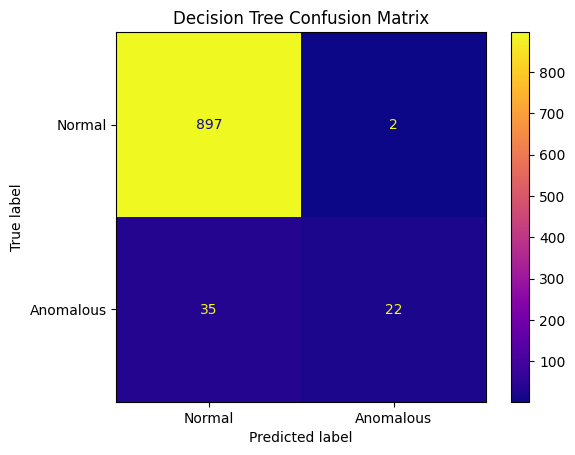

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
tree_model=DecisionTreeClassifier(
    max_depth=4,
    random_state=726)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred_tree))
tree_accuracy = accuracy_score(y_test, y_pred_tree)
print("\nDecision Tree Accuracy:")
print(round(tree_accuracy, 4))
cm=confusion_matrix(y_test, y_pred_tree)
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomalous"]
)

disp.plot(cmap="plasma")
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Interpretation

The Decision Tree achieved an overall accuracy of 96.13%, indicating that the physical dimensions of the tablets contain strong structural signals related to anomaly classification.

The model performed especially well for ordinary tablets, achieving a recall of 1.00 for the non-anomalous category. This suggests that most economic tablets follow relatively consistent dimensional patterns.

Performance for anomalous tablets was more limited, with a recall of 0.39 despite a high precision of 0.92. This means that when the model predicts a tablet as anomalous, the prediction is usually correct, but many anomalous tablets still overlap with ordinary dimensional ranges.

Archaeologically, this suggests that anomalous tablets do not form a single isolated group. Instead, they likely represent multiple forms of structural irregularity distributed across the broader dimensional space.



### Visualizing the Decision Tree

Decision Trees are useful archaeologically because their classification logic can be interpreted directly through dimensional thresholds.

The visualization below shows how the model partitions tablet geometry using combinations of:
- height
- width
- thickness

These splits help identify which physical measurements contribute most strongly to anomalous classification.

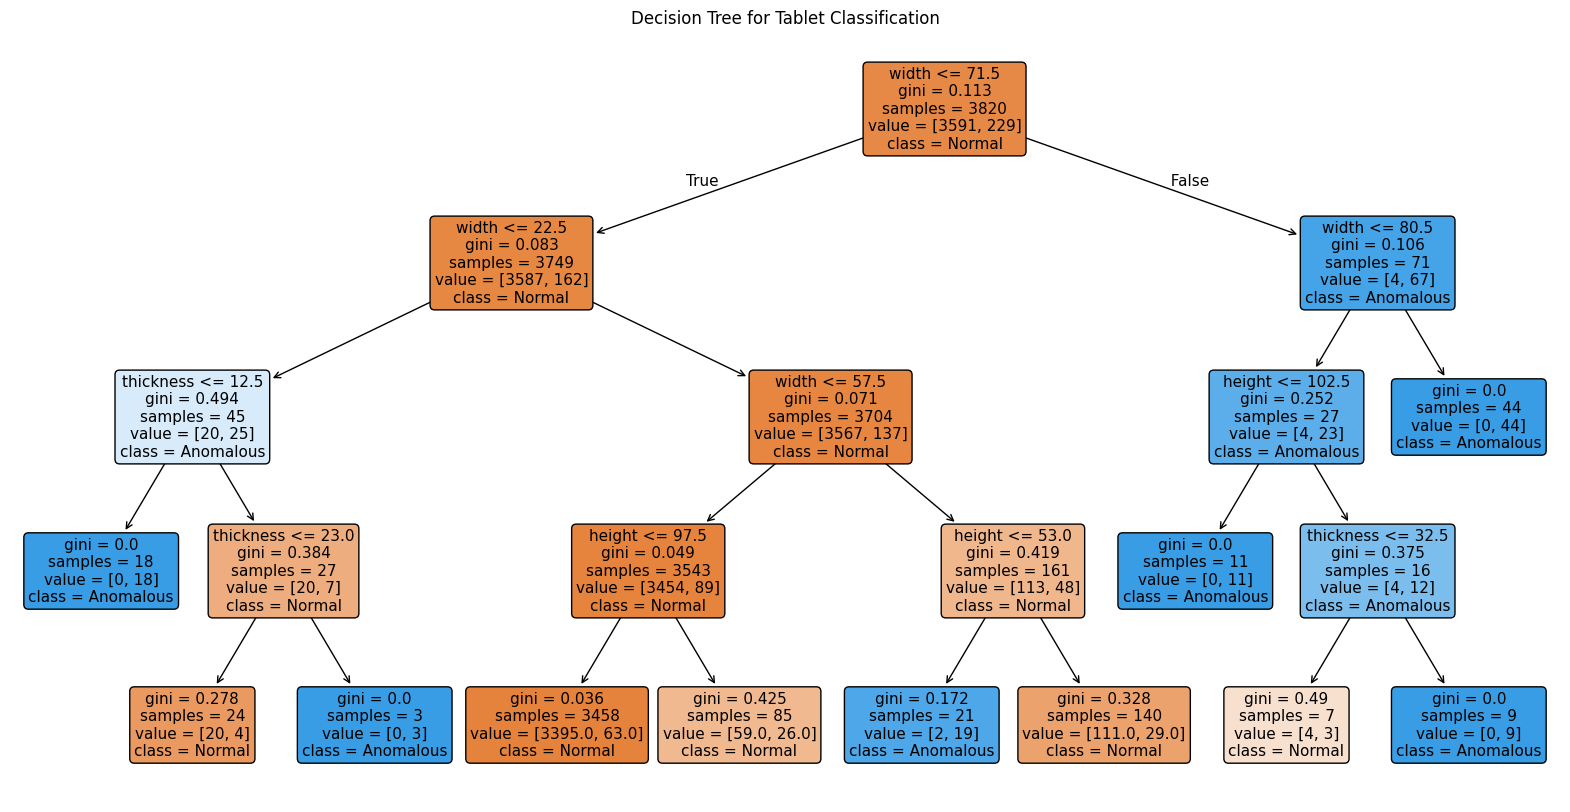

In [20]:
from sklearn import tree
plt.figure(figsize=(20, 10))
tree.plot_tree(
    tree_model,
    feature_names=["height", "width", "thickness"],
    class_names=["Normal", "Anomalous"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Tablet Classification")
plt.show()

## Interpretation of the Decision Tree Structure

- The Decision Tree reveals that **width** is the dominant structural variable in the classification process, appearing at the root node with the first major split at **71.5 units**. This indicates that horizontal tablet size plays the strongest role in separating ordinary and anomalous tablets within the dataset.

- One of the clearest patterns emerges in the right branch of the tree. Tablets with widths greater than **71.5** are classified almost entirely as anomalous, and widths above **80.5** produce a completely pure anomalous node containing **44 tablets**. This suggests that unusually wide tablets formed a structurally distinct category within the broader corpus of economic records.

- The left branch captures the overwhelming majority of the dataset and represents the dominant dimensional structure of ordinary tablets. Within this region, the tree identifies a large central cluster of tablets characterized by moderate widths and heights, ultimately producing a major normal node containing **3458 tablets**. This likely reflects the standardized geometric core of routine Babylonian administrative production.

- The tree also identifies smaller but important anomalous subgroups. Extremely narrow and thin tablets, particularly those with widths below **22.5** and thickness below **12.5**, form isolated anomalous regions despite their small size. This suggests that anomalies were not limited to oversized tablets alone, but also included unusually compact forms.

- Another interesting branch appears among tablets with widths between **57.5** and **71.5**. Within this range, shorter tablets with heights below **53.0** are classified as anomalous, while taller examples return to the normal category. This indicates that anomaly classification depends not on single dimensions independently, but on combinations of measurements interacting together.

Overall, the tree suggests that anomalous tablets emerge through multiple structural pathways rather than a single geometric pattern. Some anomalies are associated with unusually large widths, while others arise from unusually compact or disproportionate dimensional combinations.

This reinforces the broader argument that nonlinear machine learning models are capable of identifying hidden patterns within the archaeological dataset.


## Dimensions that matter

Decision Trees estimate how strongly each measurement contributes to classification by tracking how frequently and effectively variables reduce impurity during branching.

Feature importance scores do not indicate historical causation directly, but they help identify which physical dimensions carry the strongest structural signals within the dataset.

This is archaeologically useful because it allows the analysis to move beyond visual inspection of the tree toward a more systematic comparison of dimensional influence.

  Measurement  Importance
1       width    0.760971
0      height    0.153138
2   thickness    0.085891


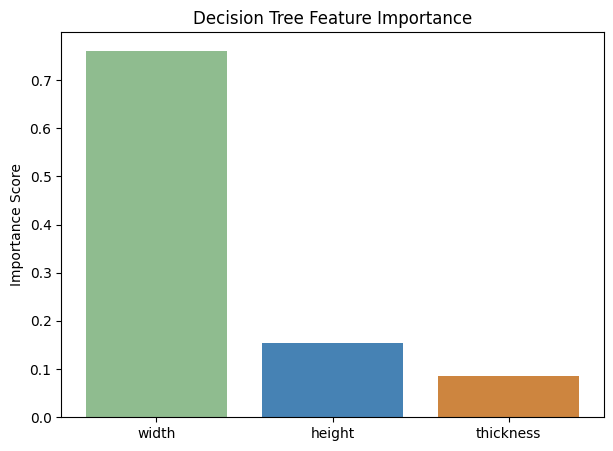

In [21]:
importance_df=pd.DataFrame({
    "Measurement": X.columns,
    "Importance": tree_model.feature_importances_
})
importance_df=importance_df.sort_values(
    by="Importance",
    ascending=False)
print(importance_df)
plt.figure(figsize=(7, 5))
plt.bar(
    importance_df["Measurement"],
    importance_df["Importance"],
    color=["darkseagreen", "steelblue", "peru"])
plt.title("Decision Tree Feature Importance")
plt.ylabel("Importance Score")
plt.show()

## Interpretation of Dimensional Importance

The results show that width is by far the most influential measurement in the Decision Tree classification process, contributing approximately 76.1% of the total importance score. This strongly supports the earlier tree visualization, where width appeared repeatedly near the upper decision levels.

This suggests that horizontal tablet proportions played a major role in distinguishing ordinary economic records from structurally anomalous tablets.

In comparison, height contributed approximately 15.3% of the classification importance, while thickness contributed only 8.6%. Although both variables still influenced the model, their impact was substantially smaller than width.

This imbalance indicates that anomaly formation within the dataset is driven primarily by variation in tablet width rather than by overall size alone.

The results are particularly interesting because thickness initially appeared visually significant due to its strong skewness and extreme outliers. However, the tree-based model suggests that those extreme thickness values occur less consistently across the broader classification structure than width-based variation.

Overall, the analysis suggests that width may have functioned as one of the strongest structural constraints within the production of Old Babylonian economic tablets, while deviations from typical width ranges were more strongly associated with anomalous forms.

---


## Random Forest Classification

Although Decision Trees are highly interpretable, individual trees can become sensitive to local variations in the dataset. Small changes in the training data may produce different branching structures and decision thresholds.

Random Forest models address this limitation by combining a large number of Decision Trees into a single ensemble system.

Instead of relying on one tree alone, the model trains multiple trees on randomized subsets of the archaeological dataset and aggregates their predictions collectively. This generally produces more stable classification performance and reduces overfitting.

For archaeological datasets, ensemble methods are especially useful because material evidence often contains:
- irregular preservation
- uneven sampling
- structurally overlapping observations

The Random Forest model therefore helps evaluate whether the dimensional patterns identified earlier remain stable across multiple decision structures rather than a single branching system.

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=726
)
rf_model.fit(X_train, y_train)
y_pred_rf=rf_model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf))
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("\nRandom Forest Accuracy:")
print(round(rf_accuracy, 4))

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       899
           1       0.97      0.49      0.65        57

    accuracy                           0.97       956
   macro avg       0.97      0.75      0.82       956
weighted avg       0.97      0.97      0.96       956


Random Forest Accuracy:
0.9686


## Interpretation of Random Forest Performance

The Random Forest model achieved an overall accuracy of **96.86%**, slightly improving upon the earlier Decision Tree classifier.

More importantly, the model showed a noticeable improvement in anomaly detection performance. The recall for anomalous tablets increased from **0.39** in the single Decision Tree model to **0.49** in the Random Forest model, while maintaining a very high precision of **0.97**.

This improvement suggests that ensemble learning captures structural variation more effectively than a single branching system alone. By combining multiple trees trained on randomized subsets of the dataset, the Random Forest is better able to identify overlapping or partially ambiguous dimensional patterns within the anomalous category.

The model also maintained extremely strong performance for ordinary tablets, with a recall of **1.00** for the normal class. This reinforces the earlier observation that most economic tablets occupy a relatively stable geometric range.

Archaeologically, the improved anomaly recall is important because it indicates that anomalous tablets likely do not follow a single structural pathway. Instead, multiple dimensional configurations appear to contribute to irregular tablet geometry, making ensemble-based classification more suitable for capturing that complexity.

## Dimensions that matter

Random Forest models combine many independent Decision Trees, their importance scores are generally more stable than those produced by a single tree.

Examining these scores helps identify whether the dimensional patterns observed earlier remain consistent across the broader ensemble structure.

  Measurement  Importance
1       width    0.447327
2   thickness    0.284229
0      height    0.268444


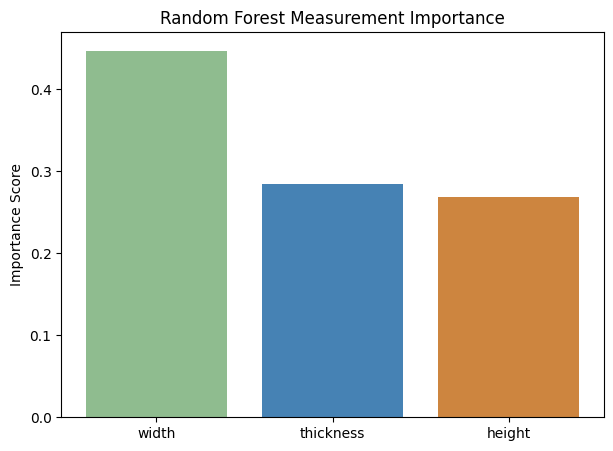

In [24]:
rf_importance_df = pd.DataFrame({
    "Measurement": X.columns,
    "Importance": rf_model.feature_importances_
})
rf_importance_df = rf_importance_df.sort_values(
    by="Importance",
    ascending=False
)
print(rf_importance_df)
plt.figure(figsize=(7, 5))
plt.bar(
    rf_importance_df["Measurement"],
    rf_importance_df["Importance"],
    color=["darkseagreen", "steelblue", "peru"]
)
plt.title("Random Forest Measurement Importance")
plt.ylabel("Importance Score")
plt.show()

## Interpretation

The Random Forest importance scores reveal a more balanced dimensional structure than the earlier Decision Tree model.

Although width remains the most influential variable with an importance score of approximately **44.7%**, its dominance is substantially reduced compared to the single-tree classification, where width contributed more than **76%** of the total importance.

At the same time, the importance of both thickness (**28.4%**) and height (**26.8%**) increases considerably within the ensemble model.

The results suggest that anomalous tablets are not defined by width alone. Instead, anomaly formation appears to emerge from more complex geometric relationships involving all three physical measurements.

In particular, the increased contribution of thickness within the Random Forest model indicates that tablet depth may play a more important secondary role when multiple structural pathways are considered simultaneously.

---



## Cross-Validation of the Random Forest Model

A single train-test split provides only one estimate of model performance. To evaluate whether the observed classification results remain stable across different subsets of the archaeological dataset, cross-validation is applied to the Random Forest model.

Cross-validation repeatedly trains and evaluates the model on different partitions of the data, producing a more reliable estimate of overall performance stability.

This is especially important for archaeological datasets because:
- anomalous observations are relatively rare
- dimensional variation may be unevenly distributed
- certain structural patterns may appear differently across subsets

The following section applies 5-fold cross-validation to examine the consistency of the ensemble model across multiple training configurations.

In [25]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)
print("Cross-Validation Scores:\n")
print(cv_scores)
print("\nMean Cross-Validation Accuracy:")
print(round(cv_scores.mean(), 5))
print("\nStandard Deviation:")
print(round(cv_scores.std(), 5))

Cross-Validation Scores:

[0.96129707 0.96753927 0.98848168 0.96544503 0.96963351]

Mean Cross-Validation Accuracy:
0.97048

Standard Deviation:
0.00941


## Interpretation

The Random Forest model achieved a mean cross-validation accuracy of **97.05%** across five folds, with a relatively small standard deviation of **0.009**.

The consistency of the validation scores suggests that the model remains stable across different subsets of the dataset.
This stability strengthens the reliability of the dimensional patterns identified earlier and indicates that the geometric relationships associated with anomalous tablets persist across multiple sampling configurations.

---


## AdaBoost Classification

Unlike Random Forest models, which combine many independent trees, AdaBoost builds models sequentially by increasing attention toward observations that were previously misclassified.

This approach is useful for the present dataset because anomalous tablets occupy relatively small and structurally overlapping regions within the dimensional space.

By focusing on difficult observations, AdaBoost may identify subtle irregularities that simpler models fail to separate consistently.

In [26]:
from sklearn.ensemble import AdaBoostClassifier
ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.8,
    random_state=726
)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred_ada))
ada_accuracy=accuracy_score(y_test, y_pred_ada)
print("\nAdaBoost Accuracy:")
print(round(ada_accuracy, 4))

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       899
           1       0.82      0.40      0.54        57

    accuracy                           0.96       956
   macro avg       0.89      0.70      0.76       956
weighted avg       0.95      0.96      0.95       956


AdaBoost Accuracy:
0.9592


## Interpretation of AdaBoost Performance

The AdaBoost model achieved an overall accuracy of **95.92%**, which is slightly lower than the Random Forest classifier.

For anomalous tablets, the model produced a recall of **0.40** and a precision of **0.82**. Compared to the Random Forest model, AdaBoost identified fewer anomalous tablets correctly and produced less stable anomaly classification overall.

This suggests that although boosting methods can focus on difficult observations, the dimensional overlap between ordinary and anomalous tablets remains substantial within the dataset.

The Random Forest model therefore appears to provide the strongest balance between stability and anomaly detection performance among the ensemble approaches tested so far.

---

## Model Comparison

After evaluating the individual classifiers, the next step is to compare their overall performance directly.

This comparison helps identify which ensemble strategy performs most effectively for the archaeological dataset while also showing how different models respond to structurally anomalous tablets.

In [27]:
comparison_df=pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "AdaBoost"
    ],

    "Accuracy": [
        tree_accuracy,
        rf_accuracy,
        ada_accuracy
    ],

    "Anomaly Recall": [
        0.39,
        0.49,
        0.40
    ],

    "Anomaly Precision": [
        0.92,
        0.97,
        0.82
    ]
})
comparison_df=comparison_df.round(4)
print(comparison_df)

           Model  Accuracy  Anomaly Recall  Anomaly Precision
0  Decision Tree    0.9613            0.39               0.92
1  Random Forest    0.9686            0.49               0.97
2       AdaBoost    0.9592            0.40               0.82


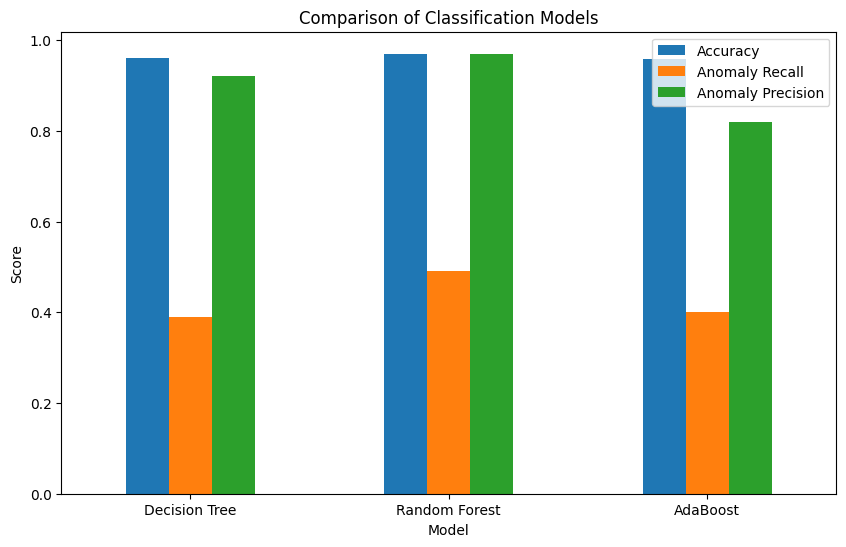

In [28]:
comparison_plot = comparison_df.set_index("Model")
comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Interpretation of Model Comparison

Among all evaluated models, the *Random Forest classifier achieved the strongest* overall performance with an accuracy of **96.86%**, an anomaly recall of **0.49**, and an anomaly precision of **0.97**.

Compared to the single Decision Tree and AdaBoost models, the Random Forest identified a larger proportion of anomalous tablets while maintaining highly reliable predictions. This suggests that ensemble-based averaging across multiple decision structures is particularly effective for capturing the overlapping dimensional relationships present within the archaeological dataset.

The Decision Tree model remained highly interpretable and achieved strong precision (**0.92**) for anomalous tablets, but its lower recall (**0.39**) indicates that many structurally unusual tablets were still absorbed into the dominant normal category.

AdaBoost produced the weakest anomaly precision (**0.82**) among the evaluated models, suggesting greater instability when attempting to separate rare geometric forms from the broader tablet population.

The comparison indicates that anomalous tablets are best understood through ensemble methods.

## SHAP-Based Interpretation

While feature importance scores identify which measurements contribute most strongly to classification overall, they do not explain how individual dimensional values influence specific predictions.

SHAP (SHapley Additive exPlanations) addresses this limitation by estimating how each measurement contributes to the prediction of a particular observation.

This is especially valuable archaeologically because it allows the analysis to move beyond global importance rankings toward local structural interpretation. Rather than asking only which dimensions matter most, SHAP helps explain:

- why certain tablets are classified as anomalous?
- which measurements push predictions toward anomaly?
- how dimensional interactions vary across the dataset?

The following section applies SHAP analysis to the Random Forest model, which produced the strongest overall classification performance among the evaluated ensemble methods

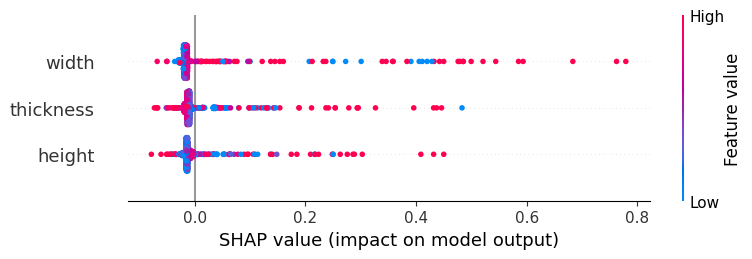

In [31]:
import shap
explainer=shap.TreeExplainer(rf_model)
shap_values=explainer.shap_values(X_test)
shap.summary_plot(shap_values[:, :, 1],X_test,feature_names=X.columns)

## Interpretation

The SHAP analysis provides a more detailed view of how the Random Forest model interprets dimensional variation within the archaeological dataset. Unlike earlier feature importance scores, the SHAP plot reveals how specific measurement values influence individual anomaly predictions.

The overall structure of the plot shows a strong concentration of tablets clustered close to the zero baseline across all three dimensions. This indicates that most tablets contribute very little toward anomalous classification and occupy a relatively stable geometry within the dataset.

The most influential variable remains **width**. Low and moderate width values, represented primarily by blue and purple points, remain concentrated around the neutral region of the model. In contrast, large width values form a long positive SHAP tail extending strongly toward anomaly prediction.

Larger *width* values sharply increase the likelihood of anomalous classification, suggesting that horizontal expansion was one of the strongest indicators of geometric irregularity within the dataset.

*Thickness* and *height* show similar but less observed trends. Most ordinary tablets remain concentrated around moderate values, while exceptionally thick or tall tablets contribute more strongly toward anomaly predictions.

Archaeologically, this suggests that anomalous tablets were generally associated with expanded geometry rather than smaller or reduced forms. The results also support the earlier Random Forest findings by showing that anomaly formation depends on a combination of dimensions rather than a single measurement alone.

Taken together, the SHAP analysis suggests that the anomalous tablets identified in this study are not simply random irregular cases. Instead, they appear to represent a smaller but structurally distinct group within the broader archaeological corpus, often characterized by unusually expanded physical dimensions.

---


## What does the Analysis actually reveal?

The results from this notebook suggest that the physical structure of Old Babylonian economic tablets was far more organized than it may initially appear. Although the dataset contains thousands of tablets, most of them remained concentrated within a relatively stable dimensional range, especially in terms of width and thickness. This pattern was visible from the early distribution plots, where the majority of tablets formed dense central clusters while only a small number extended into extreme ranges.

At the same time, the machine learning models consistently identified a smaller group of structurally unusual tablets. The Decision Tree model showed that tablets with widths above roughly **71.5 units** were frequently classified as anomalous, while the SHAP analysis further confirmed that unusually large width values strongly pushed predictions toward anomaly classification.

One of the interesting findings from the analysis was that width consistently appeared as the most important measurement across different models. In the Decision Tree model, width contributed nearly 76% of the total classification importance, while in the Random Forest model it still remained the strongest dimension with an importance score of about 44.7%.

The Random Forest model also produced the strongest overall classification performance, achieving an accuracy of **96.86%** with improved anomaly recall compared to the single Decision Tree model. This suggests that anomalous tablets are not defined by one simple rule, but instead emerge through multiple overlapping dimensional relationships that ensemble methods can capture more effectively.

Another interesting finding is that the anomalous tablets are mostly linked with larger physical dimensions rather than smaller ones. In the SHAP analysis, higher values of width, height, and thickness consistently pushed the model toward predicting a tablet as anomalous, while more moderate measurements were usually associated with normal administrative tablets.

Taken together, the results indicate that these unusual tablets are not simply accidental errors in how the clay was moulded. Rather, they represent a highly specific, unique group hidden within the main archive of economic records. It is particularly striking that by looking strictly at their physical size, without reading any text, the models were able to uncover intentional, repeating patterns in how these specific tablets were shaped.

This demonstrates how interpretable machine learning methods can contribute meaningfully to archaeological research by helping reveal patterns that may not be immediately visible through manual inspection alone.

---

# **Conclusion**

Across both notebooks, this project explored how computational methods can be applied to archaeological datasets in order to study the physical structure of Old Babylonian economic tablets from the Cuneiform Digital Library Initiative archive.

The first notebook focused on building the analytical pipeline. Archaeological metadata was loaded and processed using PySpark, dimensional measurements were cleaned and standardized, and anomaly detection methods were applied using clustering and distance-based approaches. The analysis showed that even simple physical measurements such as height, width, and thickness were sufficient to identify structurally unusual tablets within the large dataset.

The second notebook moved beyond anomaly detection and focused on interpretation. Decision Trees, Random Forests, AdaBoost, cross-validation, and SHAP analysis were used to examine how dimensional relationships contribute to anomalous classification.

Several consistent patterns emerged throughout the analysis:

- most tablets followed relatively stable dimensional ranges
- anomalous tablets formed only a small proportion of the dataset
- width repeatedly appeared as the strongest structural indicator
- ensemble models performed better than single-tree classification approaches

The Random Forest model achieved the strongest balance between accuracy and anomaly detection performance, while SHAP analysis helped explain how unusually large measurements increased the probability of anomalous classification.

Overall, the project demonstrates that machine learning models can do more than simply classifying archaeological objects. When interpreted carefully, they can also help reveal hidden patterns within ancient material records.

Even with only three physical measurements,both the notebooks were able to identify geometric patterns that may reflect underlying administrative practices, scribal conventions, or production differences within the Old Babylonian world.
